# Data Understanding
The first part of this assignment is to explore the data and to define the machine learning task. You should perform EDA as an initial step to analyse the liver cirrhosis set. The analyses should be conducted on the given training set. The analyses should explore the data from the four different aspects:
-  Describe the summary statistics of the data. This should include the number of instances and number of features. Report the number of categorical and numerical features separately. 
- Identify the top three numerical features with the highest Pearson correlation with the target variable Status, and report their correlation values.
- Plot the distributions of the three numerical features identified in the previous question and the target variable using histograms. One histogram for each feature/variable. Describe how to determine the number of bins to draw the histograms. Based on the histograms, describe the shape of their distributions (i.e. Positive or Negative or Zero) with respect to their skewness and kurtosis.
- Check for missing values. Write a paragraph to briefly summarise how many features containing missing values and the percentage of missing values for each incomplete feature.

Provide answers to above questions in your report. Submit your Jupyter Notebook file (EDA.ipynb) or your Python file (EDA.py) that shows how you get the answers.

In [118]:
# Load our VIPs (very important packages)
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np
import seaborn as sns # for data visualization
import warnings
warnings.filterwarnings("ignore")

In [119]:
df = pd.read_csv('Training.csv')
df = df.rename(columns={'Tryglicerides': 'Triglycerides'})
df.head()

,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Triglycerides,Platelets,Prothrombin,Stage
0,0,D-penicillamine,19567,F,N,Y,N,S,2.3,260.0,3.18,231.0,11320.2,105.78,94.0,216.0,12.4,3.0
1,0,Placebo,17246,F,N,Y,N,N,2.1,262.0,3.48,58.0,2045.0,89.90,84.0,225.0,11.5,4.0
2,1,Placebo,17874,F,N,Y,N,S,8.7,310.0,3.89,107.0,637.0,117.00,242.0,298.0,9.6,2.0
3,0,D-penicillamine,15895,F,Y,Y,Y,S,17.1,674.0,2.53,207.0,2078.0,182.90,598.0,268.0,11.5,4.0
4,0,Placebo,24650,F,N,Y,N,N,8.0,468.0,2.81,139.0,2009.0,198.40,139.0,233.0,10.0,4.0


In [120]:
# Summary Statisics
## Number of Instances
## Number of Features
## Number of categorical and numerical features separately

In [121]:
df.shape

(334, 18)

In [122]:
categoricalFactors = ['Status', 'Drug', 'Sex', 'Ascites', 'Hepatomegaly', 'Spiders', 'Edema', 'Stage']
dfCat = df[categoricalFactors].astype('category')
dfCat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 334 entries, 0 to 333
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Status        334 non-null    category
 1   Drug          254 non-null    category
 2   Sex           334 non-null    category
 3   Ascites       254 non-null    category
 4   Hepatomegaly  254 non-null    category
 5   Spiders       254 non-null    category
 6   Edema         334 non-null    category
 7   Stage         329 non-null    category
dtypes: category(8)
memory usage: 3.8 KB


In [123]:
df.describe()
# Missing values in Cholesterol, Copper, Alk_Phos, SGOT, Tryglicerides, Platelets, Prothrombin, and Stage

,Status,Age,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Triglycerides,Platelets,Prothrombin,Stage
count,334.000000,334.000000,334.000000,232.000000,334.000000,252.000000,254.000000,254.000000,232.000000,325.000000,332.000000,329.000000
mean,0.613772,18458.628743,3.353892,373.297414,3.506437,98.162698,1967.518898,123.388425,124.668103,260.218462,10.764458,3.039514
std,0.487614,3860.211171,4.551418,247.550620,0.423248,89.603383,2130.869240,57.066844,67.516406,98.882826,1.080674,0.884291
min,0.000000,9598.000000,0.300000,120.000000,1.960000,9.000000,289.000000,26.350000,33.000000,62.000000,9.000000,1.000000
25%,0.000000,15593.500000,0.800000,247.000000,3.260000,41.500000,862.500000,80.485000,84.000000,192.000000,10.000000,2.000000
50%,1.000000,18414.000000,1.350000,308.500000,3.550000,71.500000,1288.500000,116.250000,108.000000,252.000000,10.600000,3.000000
75%,1.000000,21231.500000,3.575000,396.750000,3.777500,121.000000,2031.500000,153.450000,149.000000,319.000000,11.100000,4.000000
max,1.000000,28650.000000,28.000000,1775.000000,4.640000,588.000000,13862.400000,457.250000,598.000000,721.000000,18.000000,4.000000


In [124]:
# Top three numerical features with highest Pearson correlation with target variable `status` and their correlation values

In [125]:
# This method fails because the pointbiserialr function requires no missing values, and we have missing values in our dataset.
# We will drop all NaN values for the numerical factors and then run the pointbiserialr function on the cleaned dataset.

dfCleaned = df.dropna()
correlations = pd.DataFrame(columns=['Name', 'Correlation'])

numericalFactors = ['Age', 'Bilirubin', 'Cholesterol', 'Albumin', 'Copper', 'Alk_Phos', 'SGOT', 'Triglycerides', 'Platelets', 'Prothrombin']
for factor in numericalFactors:
    correlation, p_value = stats.pointbiserialr(dfCleaned['Status'], dfCleaned[factor])
    correlations.loc[len(correlations)] = [factor, correlation]
    print(f"Correlation between Status and {factor}: {correlation}, P-value: {p_value}")

correlations.sort_values(by='Correlation', key=abs, ascending=False).drop_duplicates().head(3)

Correlation between Status and Age: -0.2809514234267491, P-value: 1.735581049070844e-05
Correlation between Status and Bilirubin: -0.4337976285361258, P-value: 7.841160149687726e-12
Correlation between Status and Cholesterol: -0.1764885116614191, P-value: 0.007690994148159873
Correlation between Status and Albumin: 0.2739025089973419, P-value: 2.860795935613433e-05
Correlation between Status and Copper: -0.3277730389584504, P-value: 4.38638256316375e-07
Correlation between Status and Alk_Phos: -0.2798756890296976, P-value: 1.874784573579679e-05
Correlation between Status and SGOT: -0.23208996916490288, P-value: 0.000422287091709767
Correlation between Status and Triglycerides: -0.2033012741929929, P-value: 0.0020815389491478753
Correlation between Status and Platelets: 0.0787354795224943, P-value: 0.23738197315813875
Correlation between Status and Prothrombin: -0.4308143990948541, P-value: 1.1278079195152416e-11


,Name,Correlation
1,Bilirubin,-0.433798
9,Prothrombin,-0.430814
4,Copper,-0.327773


In [126]:
# Plot distributions of numerical features identified above and target variable with histograms - one for each
## Describe how to determine number of bins
## Easiest method would be bins = sqrt(n), where n is the number of data points, but this can lead to too many bins for large datasets.
## Our dataset isn't that big so we will try it on first
## Decribe shape of distributions with respect to their skewness and kurtosis

In [127]:
print(df.shape[0])
bins = int(np.sqrt(df.shape[0]))
print(f"Number of bins: {bins}")

334
Number of bins: 18


In [128]:
# Check for missing values
## Paragraph to describe how many features containing missing values and the percentage of missing values for each incomplete feature

In [129]:
df.isna().sum()

Status             0
Drug              80
Age                0
Sex                0
Ascites           80
Hepatomegaly      80
Spiders           80
Edema              0
Bilirubin          0
Cholesterol      102
Albumin            0
Copper            82
Alk_Phos          80
SGOT              80
Triglycerides    102
Platelets          9
Prothrombin        2
Stage              5
dtype: int64

In [130]:
missingValues = ["Drug", "Ascites", "Hepatomegaly", "Spiders", "Cholesterol", "Copper", "Alk_Phos", "SGOT", "Triglycerides", "Platelets", "Prothrombin"]

for feature in missingValues:
    print(df.groupby("Status")[feature].apply(lambda x: x.isna().mean()))


Status
0    0.240310
1    0.239024
Name: Drug, dtype: float64
Status
0    0.240310
1    0.239024
Name: Ascites, dtype: float64
Status
0    0.240310
1    0.239024
Name: Hepatomegaly, dtype: float64
Status
0    0.240310
1    0.239024
Name: Spiders, dtype: float64
Status
0    0.302326
1    0.307317
Name: Cholesterol, dtype: float64
Status
0    0.248062
1    0.243902
Name: Copper, dtype: float64
Status
0    0.240310
1    0.239024
Name: Alk_Phos, dtype: float64
Status
0    0.240310
1    0.239024
Name: SGOT, dtype: float64
Status
0    0.302326
1    0.307317
Name: Triglycerides, dtype: float64
Status
0    0.038760
1    0.019512
Name: Platelets, dtype: float64
Status
0    0.007752
1    0.004878
Name: Prothrombin, dtype: float64


lotting univariate data:
• Is data normally distributed?
• Is it unimodal/bimodal/multimodal?
• Skewness
• Left (negative) skew: long tail on the left
• Right (positive) skew: long tail on the right
• Kurtosis: tail heaviness
• Positive kurtosis: heavier tails, more extreme
values
• Negative kurtosis: lighter tails, fewer
extreme values

334
Number of bins: 18


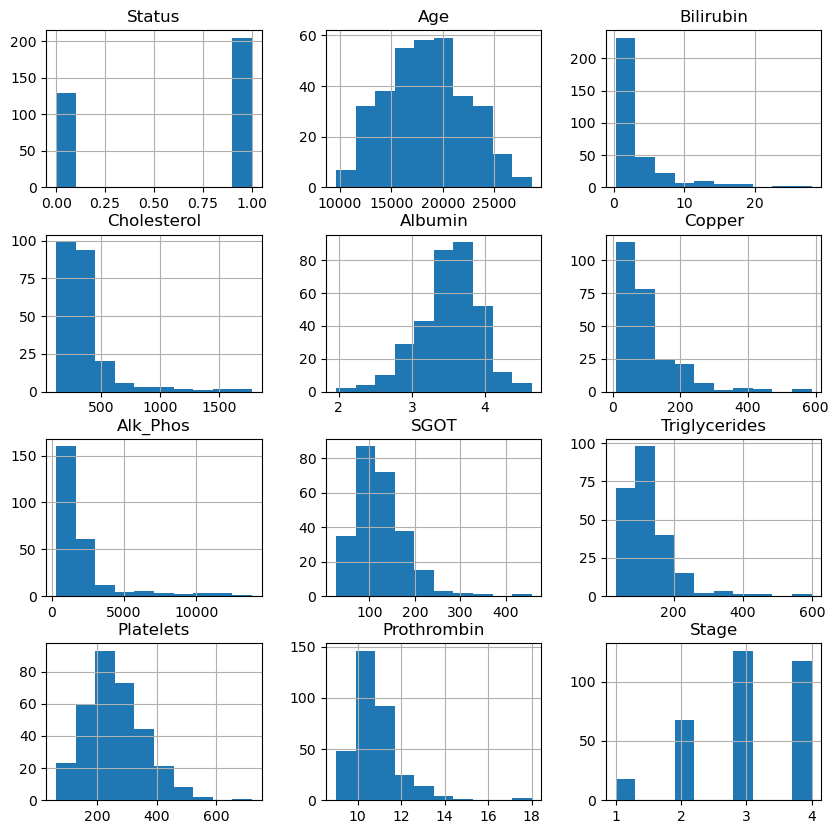

In [ ]:
print(df.shape[0])
bins = int(np.sqrt(df.shape[0]))
print(f"Number of bins: {bins}")

fig, ax = plt.subplots(figsize=(10,10))
df.hist(ax=ax);

df['age'].skew(), df['age'].kurtosis()

In [132]:
df2 = df.dropna()
dfMissing = df.drop(df2.index)

dfMissing

# Based on what we can see in the dataset, most rows with NA values share missing values in the same features, so it is likely that these rows are missing values for the same reason.
# This could be due to a specific group of patients not having certain tests done, or it could be due to data entry errors.
# It seems like this is most likely related to missing 'Drug' values, as most rows that share the same missing values also share missing 'Drug' values

# Opted to use predictive imputation to fill in those missing values

,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Triglycerides,Platelets,Prothrombin,Stage
17,0,NaN,16071,M,NaN,NaN,NaN,N,9.5,NaN,3.63,NaN,NaN,NaN,NaN,292.0,10.2,3.0
18,0,D-penicillamine,19577,F,Y,Y,Y,N,1.2,269.0,3.12,NaN,1441.0,165.85,68.0,166.0,11.1,4.0
23,0,Placebo,15857,F,N,Y,Y,S,8.5,NaN,3.34,161.0,1428.0,181.35,NaN,88.0,13.3,4.0
25,1,NaN,15341,F,NaN,NaN,NaN,N,8.1,NaN,2.82,NaN,NaN,NaN,NaN,193.0,10.4,2.0
30,1,NaN,23011,F,NaN,NaN,NaN,N,0.9,NaN,3.58,NaN,NaN,NaN,NaN,224.0,10.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
324,1,NaN,18993,F,NaN,NaN,NaN,N,1.7,NaN,3.24,NaN,NaN,NaN,NaN,231.0,10.5,3.0
327,0,NaN,23741,F,NaN,NaN,NaN,S,1.4,NaN,3.04,NaN,NaN,NaN,NaN,331.0,12.1,4.0
329,1,NaN,23011,F,NaN,NaN,NaN,N,0.6,NaN,3.94,NaN,NaN,NaN,NaN,234.0,11.5,2.0
330,1,NaN,14975,M,NaN,NaN,NaN,N,1.7,NaN,3.66,NaN,NaN,NaN,NaN,92.0,11.0,4.0
